# Generative Modeling for Atmospheric Particle Events

### A comparative study of conditional WGAN and diffusion-based generation on MAGIC telescope data

`Python` · `PyTorch` · `scikit-learn` · `Generative AI` · `Scientific Data`

## Project overview

High-energy astronomy relies on expensive observations and detailed physical simulations. This project explores whether generative neural networks can learn the structure of telescope event data and produce realistic synthetic observations.

The study compares two approaches—a conditional Wasserstein GAN and a diffusion-based generator—on measurements from the MAGIC Gamma Telescope. Both models generate event parameters conditioned on particle class, and their outputs are evaluated visually and with downstream classifiers.

## The MAGIC telescope

MAGIC (Major Atmospheric Gamma Imaging Cherenkov) is a system of two 17-meter Cherenkov telescopes designed to observe gamma rays from galactic and extragalactic sources at very high energies, from approximately 30 GeV to 100 TeV.

The observatory has supported research into gamma-ray sources such as pulsars and gamma-ray bursts.

<center><img src="img/magic1.jpg" width="1000"></center>

Resources: [MAGIC Collaboration](https://magic.mpp.mpg.de/) · [Video introduction](https://youtu.be/mjcDSR2vSU8)

## From cosmic particles to measurable events

Cosmic particles—including $\gamma$-ray photons and hadrons such as protons—interact with the atmosphere and create cascades of secondary particles. As these particles travel near the speed of light, they emit Cherenkov radiation that can be captured by ground-based telescopes.

The resulting images contain enough structural information to distinguish photon-initiated showers from hadron-initiated showers, making this a natural classification and conditional-generation problem.

<center><img src="img/shower.jpg" width="500"></center>

## Event representation

An atmospheric Cherenkov telescope records the light produced by an air shower as a geometric projection on its detector. Each event is summarized using Hillas parameters, which describe the shape, orientation, concentration, and position of the observed light cluster.

<center><img src="img/geo.jpg" width="400"></center>

Rather than generating raw images, this project models the ten-dimensional vector of physically meaningful event descriptors calculated by the telescope.

## Photon and hadron signatures

Photon- and hadron-initiated showers tend to produce clusters with different geometric characteristics. Machine-learning models can use these differences to identify the originating particle.

<center><img src="img/gamma_p.png" width="600"></center>

Because collecting observations and running detailed physical simulations can be costly, realistic synthetic event vectors may be useful for experimentation and model development. This motivates the conditional WGAN and diffusion approaches explored below.

In [ ]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## Dataset

The analysis uses the [MAGIC Gamma Telescope dataset from the UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/datasets/MAGIC+Gamma+Telescope). Each row represents one observed shower image through ten Hillas parameters and a class label indicating a photon (`g`) or hadron (`h`) event.

| Feature | Description |
|---|---|
| Length | Major axis of the ellipse (mm) |
| Width | Minor axis of the ellipse (mm) |
| Size | Base-10 logarithm of the total pixel intensity |
| Conc | Ratio of the two brightest pixels to total size |
| Conc1 | Ratio of the brightest pixel to total size |
| Asym | Projected distance from the brightest pixel to the center (mm) |
| M3Long | Cube root of the third moment along the major axis (mm) |
| M3Trans | Cube root of the third moment along the minor axis (mm) |
| Alpha | Orientation angle of the major axis (degrees) |
| Dist | Distance from the image center to the camera center (mm) |
| class | Particle category: photon (`g`) or hadron (`h`) |

In [ ]:
# read data
names = np.array(
    [
        "Length",
        "Width",
        "Size",
        "Conc",
        "Conc1",
        "Asym",
        "M3Long",
        "M3Trans",
        "Alpha",
        "Dist",
        "class",
    ]
)
data = pd.read_csv("/kaggle/input/pzad-hw1/2023/hw/hw1/data/magic04.data", header=None)
data.columns = names
print(data.shape)
data.head()

(19020, 11)


,Length,Width,Size,Conc,Conc1,Asym,M3Long,M3Trans,Alpha,Dist,class
0,28.7967,16.0021,2.6449,0.3918,0.1982,27.7004,22.0110,-8.2027,40.0920,81.8828,g
1,31.6036,11.7235,2.5185,0.5303,0.3773,26.2722,23.8238,-9.9574,6.3609,205.2610,g
2,162.0520,136.0310,4.0612,0.0374,0.0187,116.7410,-64.8580,-45.2160,76.9600,256.7880,g
3,23.8172,9.5728,2.3385,0.6147,0.3922,27.2107,-6.4633,-7.1513,10.4490,116.7370,g
4,75.1362,30.9205,3.1611,0.3168,0.1832,-5.5277,28.5525,21.8393,4.6480,356.4620,g


## Project objective

The goal is to learn the conditional distribution of telescope-event parameters for each particle type:

- $X$ is the matrix of real ten-dimensional event vectors.
- $y$ is the particle-class condition supplied to the generative models.

Hadron events are encoded as **0** and photon events as **1**. The central question is whether generated samples reproduce the statistical structure of real observations closely enough to challenge an independent classifier.

In [ ]:
# Event-level image parameters
X = data[names[:-1]].values
X = np.abs(X)

# Particle class labels
labels = data[names[-1]].values
y = np.ones((len(labels), 1))
y[labels == "h"] = 0

In [ ]:
# Sample feature vectors
X[:2]

array([[2.87967e+01, 1.60021e+01, 2.64490e+00, 3.91800e-01, 1.98200e-01,
        2.77004e+01, 2.20110e+01, 8.20270e+00, 4.00920e+01, 8.18828e+01],
       [3.16036e+01, 1.17235e+01, 2.51850e+00, 5.30300e-01, 3.77300e-01,
        2.62722e+01, 2.38238e+01, 9.95740e+00, 6.36090e+00, 2.05261e+02]])

In [ ]:
# Sample feature vectors
y[:10]

array([[1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.],
       [1.]])

In [ ]:
# Encoded class values
np.unique(y)

array([0., 1.])

## Exploratory data analysis

Each event contains ten numerical descriptors. Comparing their class-conditional distributions provides an initial view of feature scale, skewness, overlap, and the separation between photon and hadron observations.

In [ ]:
def plot_hists(X1, X2, names, label1, label2, bins=np.linspace(-3, 3, 61)):
    plt.figure(figsize=(5 * 4, 5 * 2))
    for i in range(X1.shape[1]):
        plt.subplot(3, 4, i + 1)
        plt.grid()
        plt.hist(X1[:, i], bins=bins, alpha=0.3, label=label1, color="C4")
        plt.hist(X2[:, i], bins=bins, alpha=0.3, label=label2, color="C0")
        plt.xlabel(names[i], size=14)
        plt.legend(loc="best")
    plt.tight_layout()

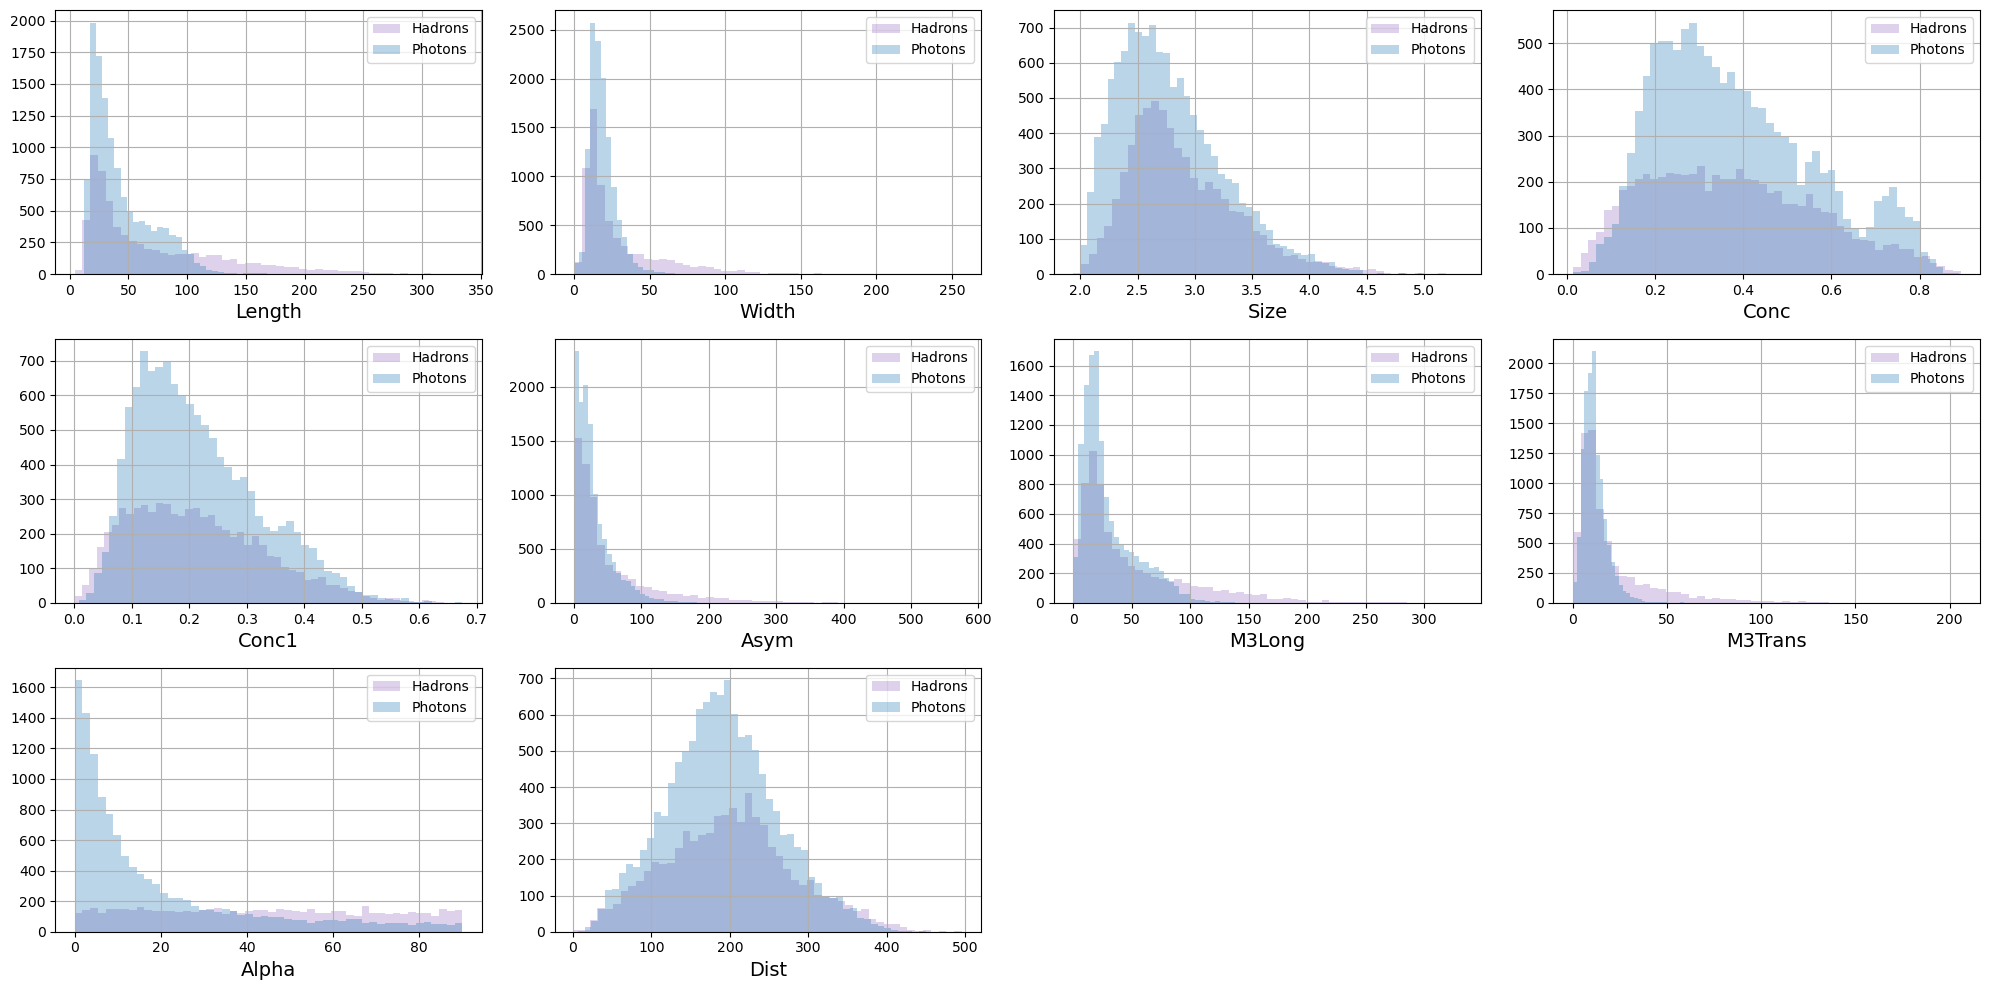

In [ ]:
plot_hists(
    X[y[:, 0] == 0], X[y[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)

## Data preprocessing

Several features exhibit long-tailed distributions, which can make optimization of generative models unstable. A quantile transformation is therefore used to map each feature to an approximately normal marginal distribution before training.

### Stratified train–test split

In [ ]:
from sklearn.model_selection import train_test_split

# train / test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, stratify = y, test_size=0.5, shuffle = True, random_state = 11
)

### Verifying class balance

The target distribution is inspected in both partitions to confirm that stratification preserved the photon–hadron class proportions.

(array([3344.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        6166.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

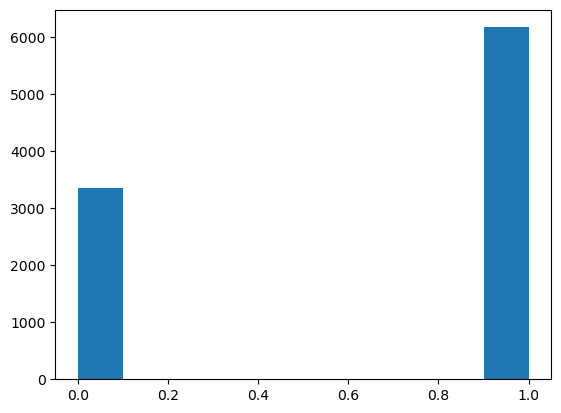

In [ ]:
plt.hist(y_test)

(array([3344.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
        6166.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

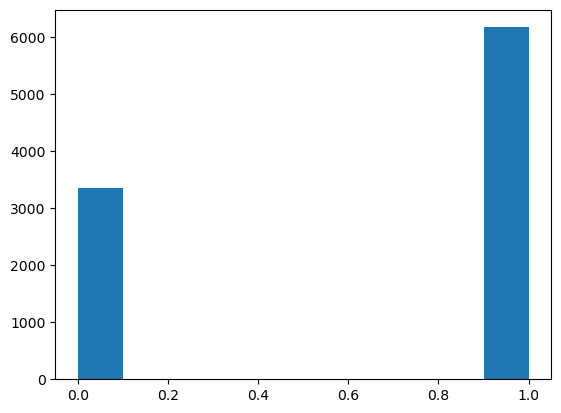

In [ ]:
plt.hist(y_train)

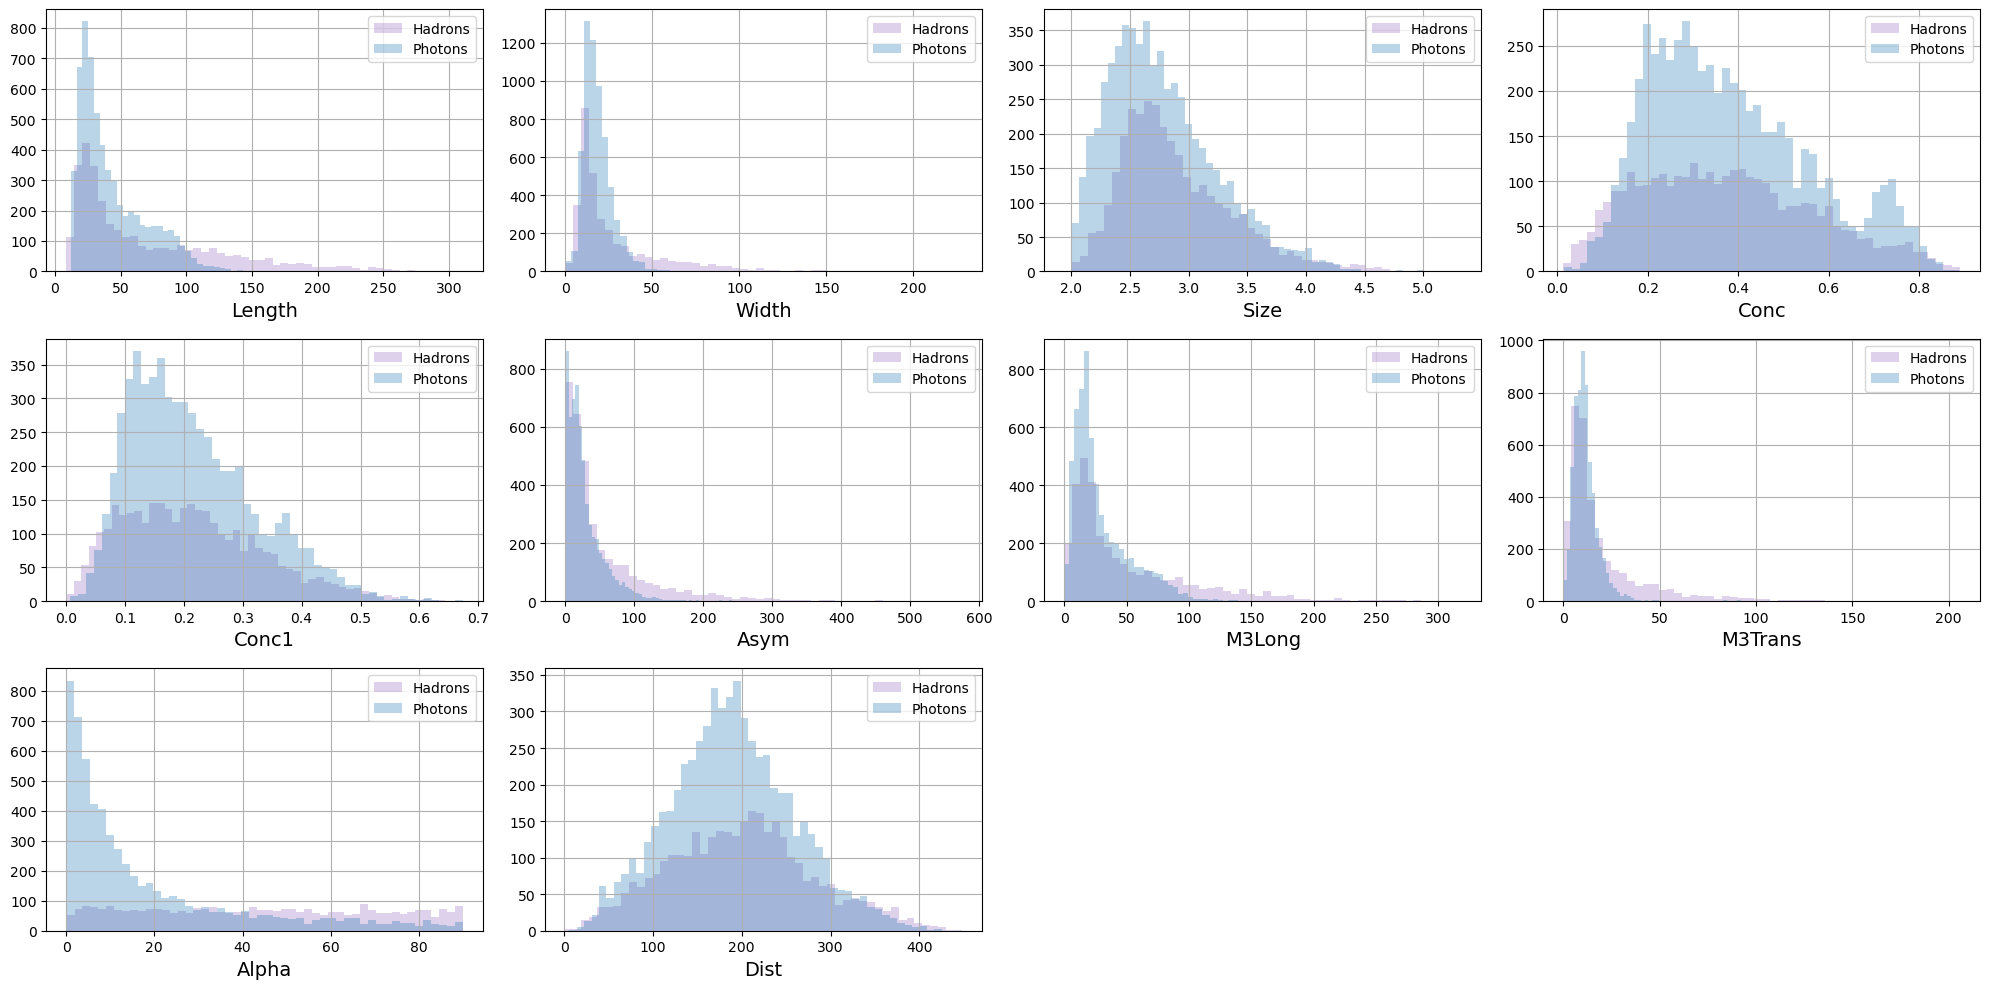

In [ ]:
plot_hists(X_train[y_train[:, 0] == 0], X_train[y_train[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)

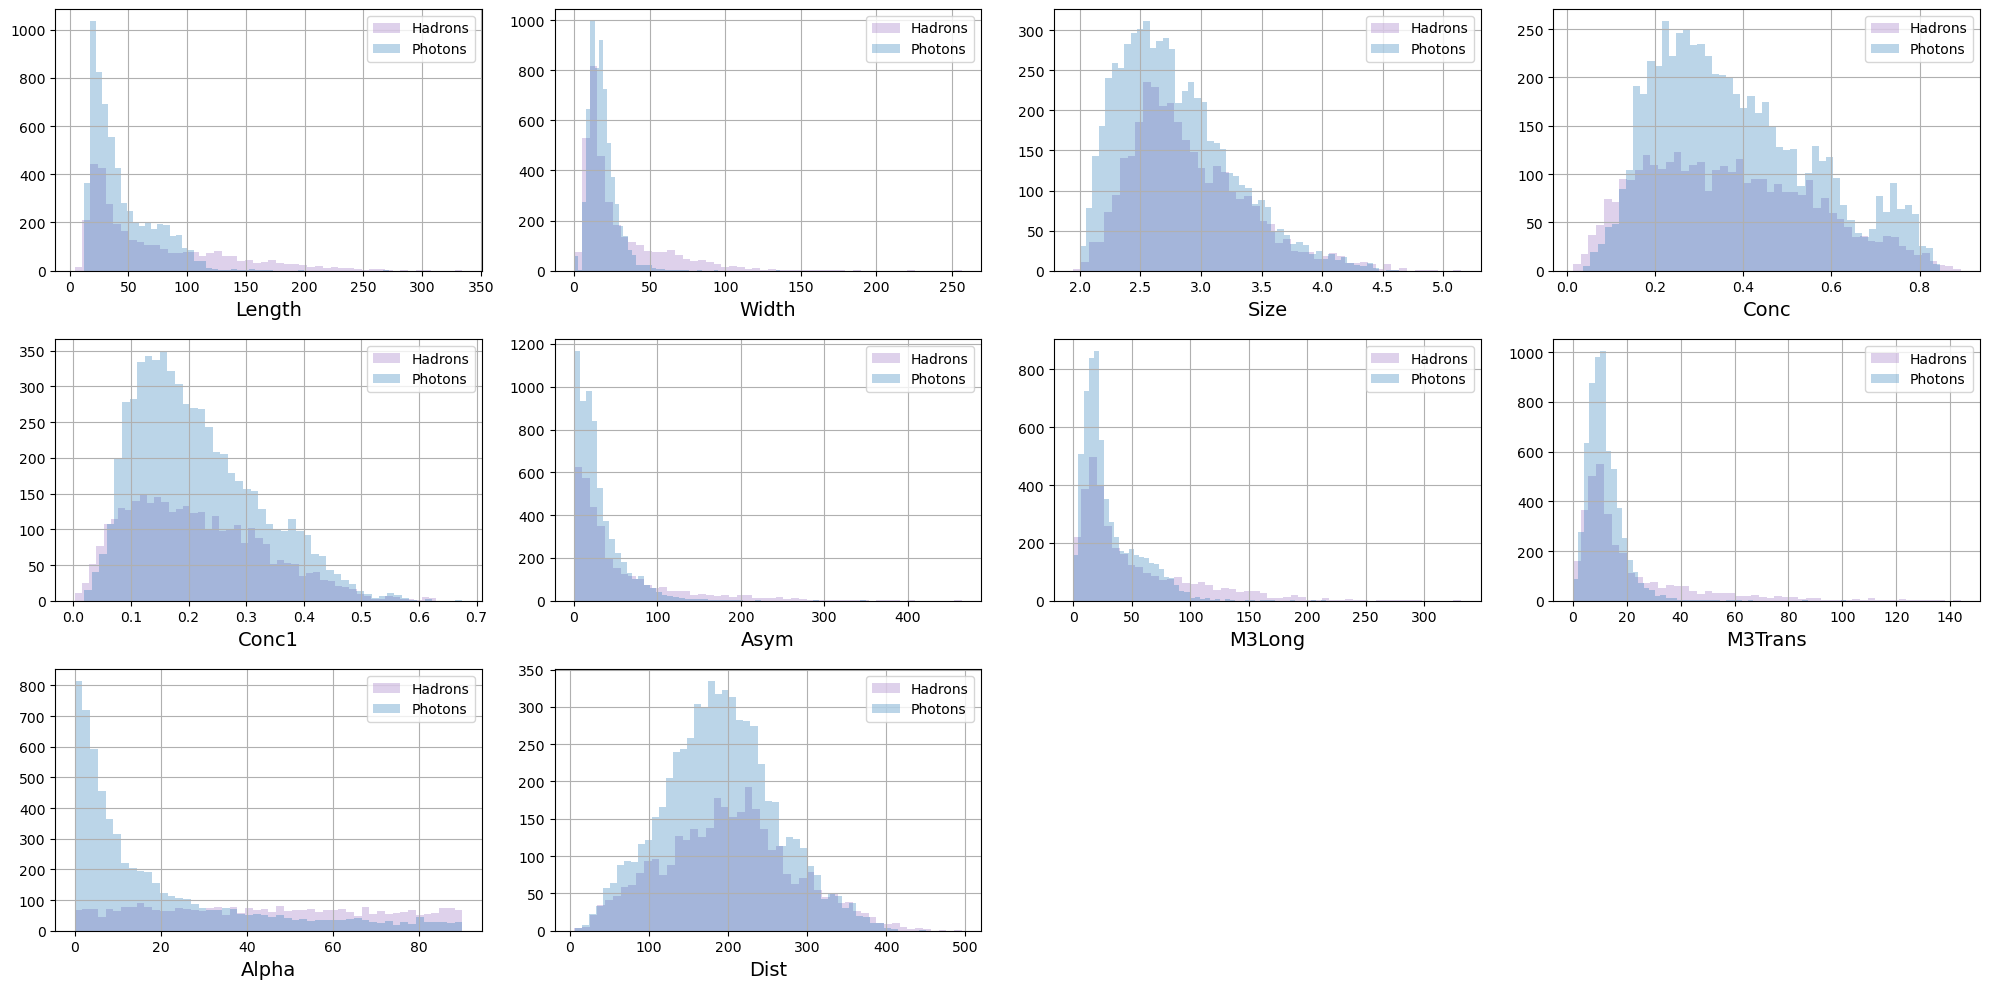

In [ ]:
plot_hists(X_test[y_test[:, 0] == 0], X_test[y_test[:, 0] == 1], names, label1="Hadrons", label2="Photons", bins=50
)

### Quantile normalization

`QuantileTransformer` is fitted only on the training data and then applied to both partitions with `output_distribution='normal'`. This avoids leaking information from the test set into preprocessing while producing feature distributions that are easier for the generative models to learn.

In [ ]:
# Model implementation
from sklearn.preprocessing import QuantileTransformer
qt = QuantileTransformer(output_distribution='normal')
X_train = qt.fit_transform(X_train)
X_test = qt.transform(X_test)
# End implementation

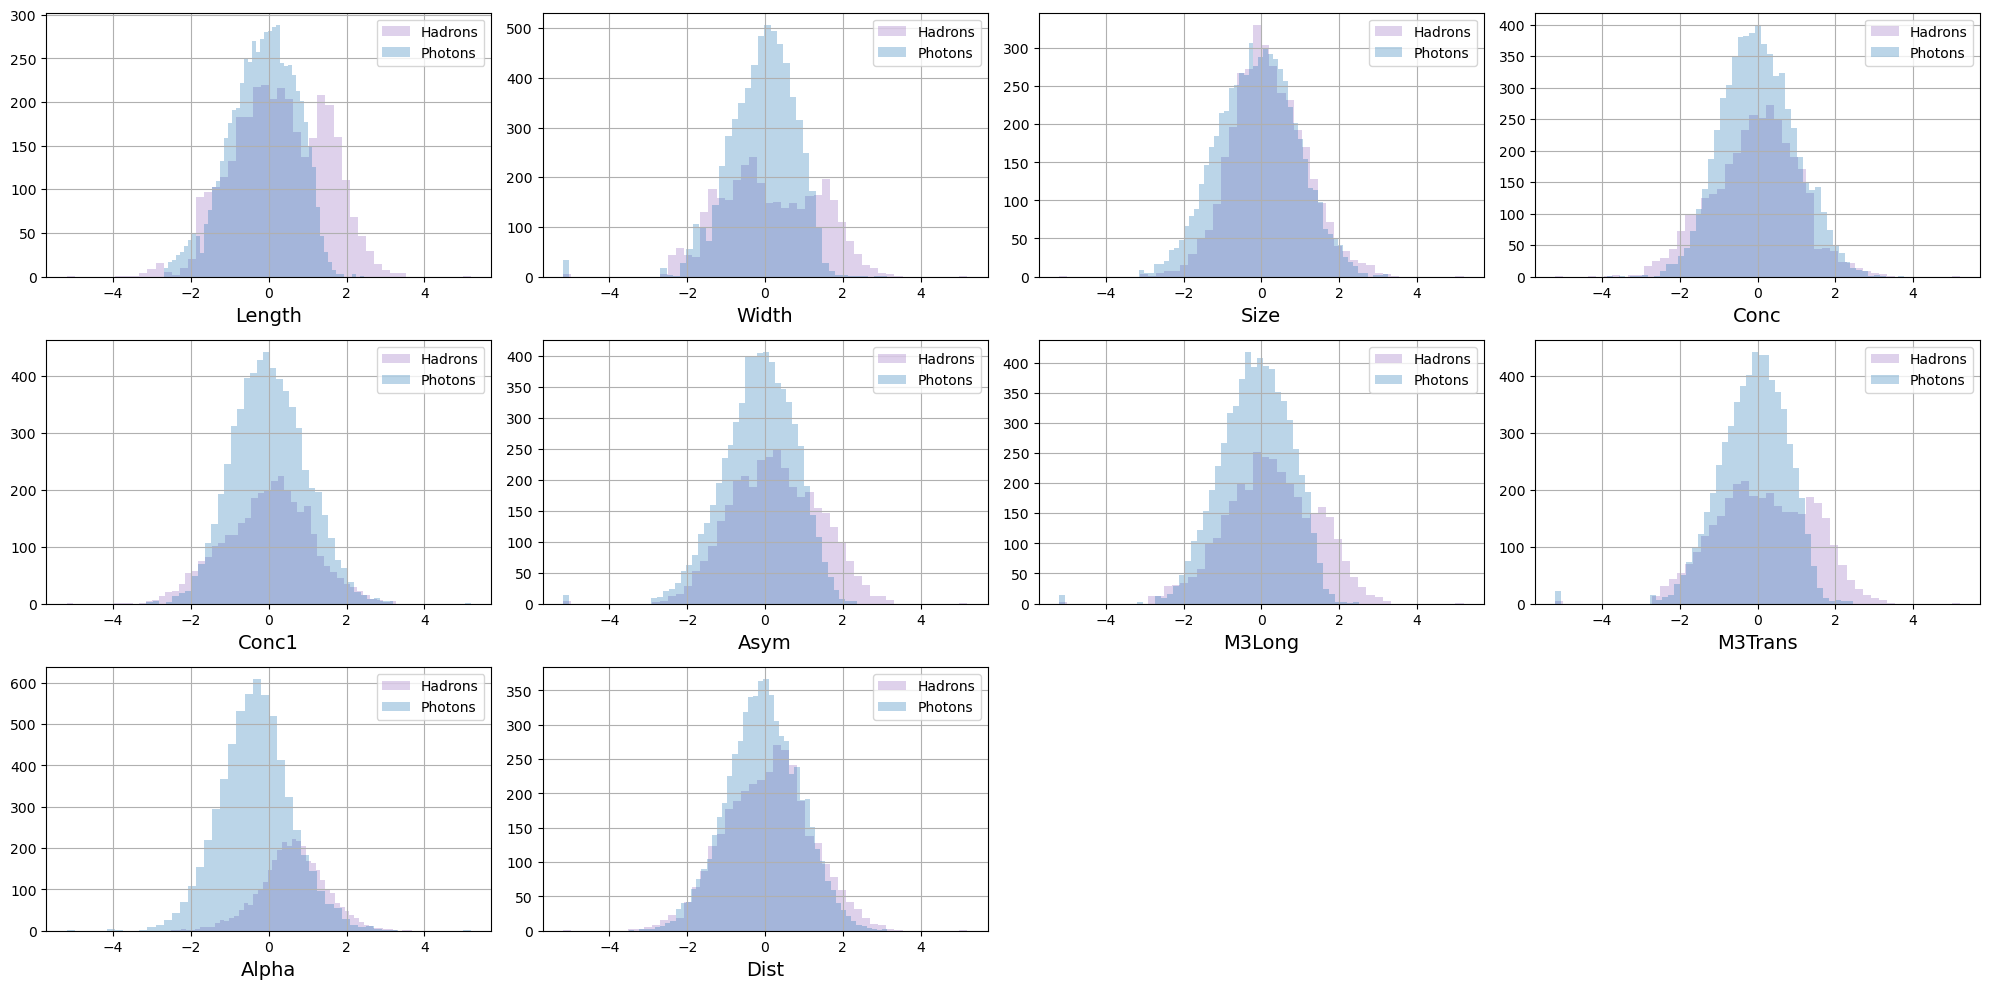

In [ ]:
plot_hists(
    X_train[y_train[:, 0] == 0],
    X_train[y_train[:, 0] == 1],
    names,
    label1="Hadrons",
    label2="Photons",
    bins=50,
)

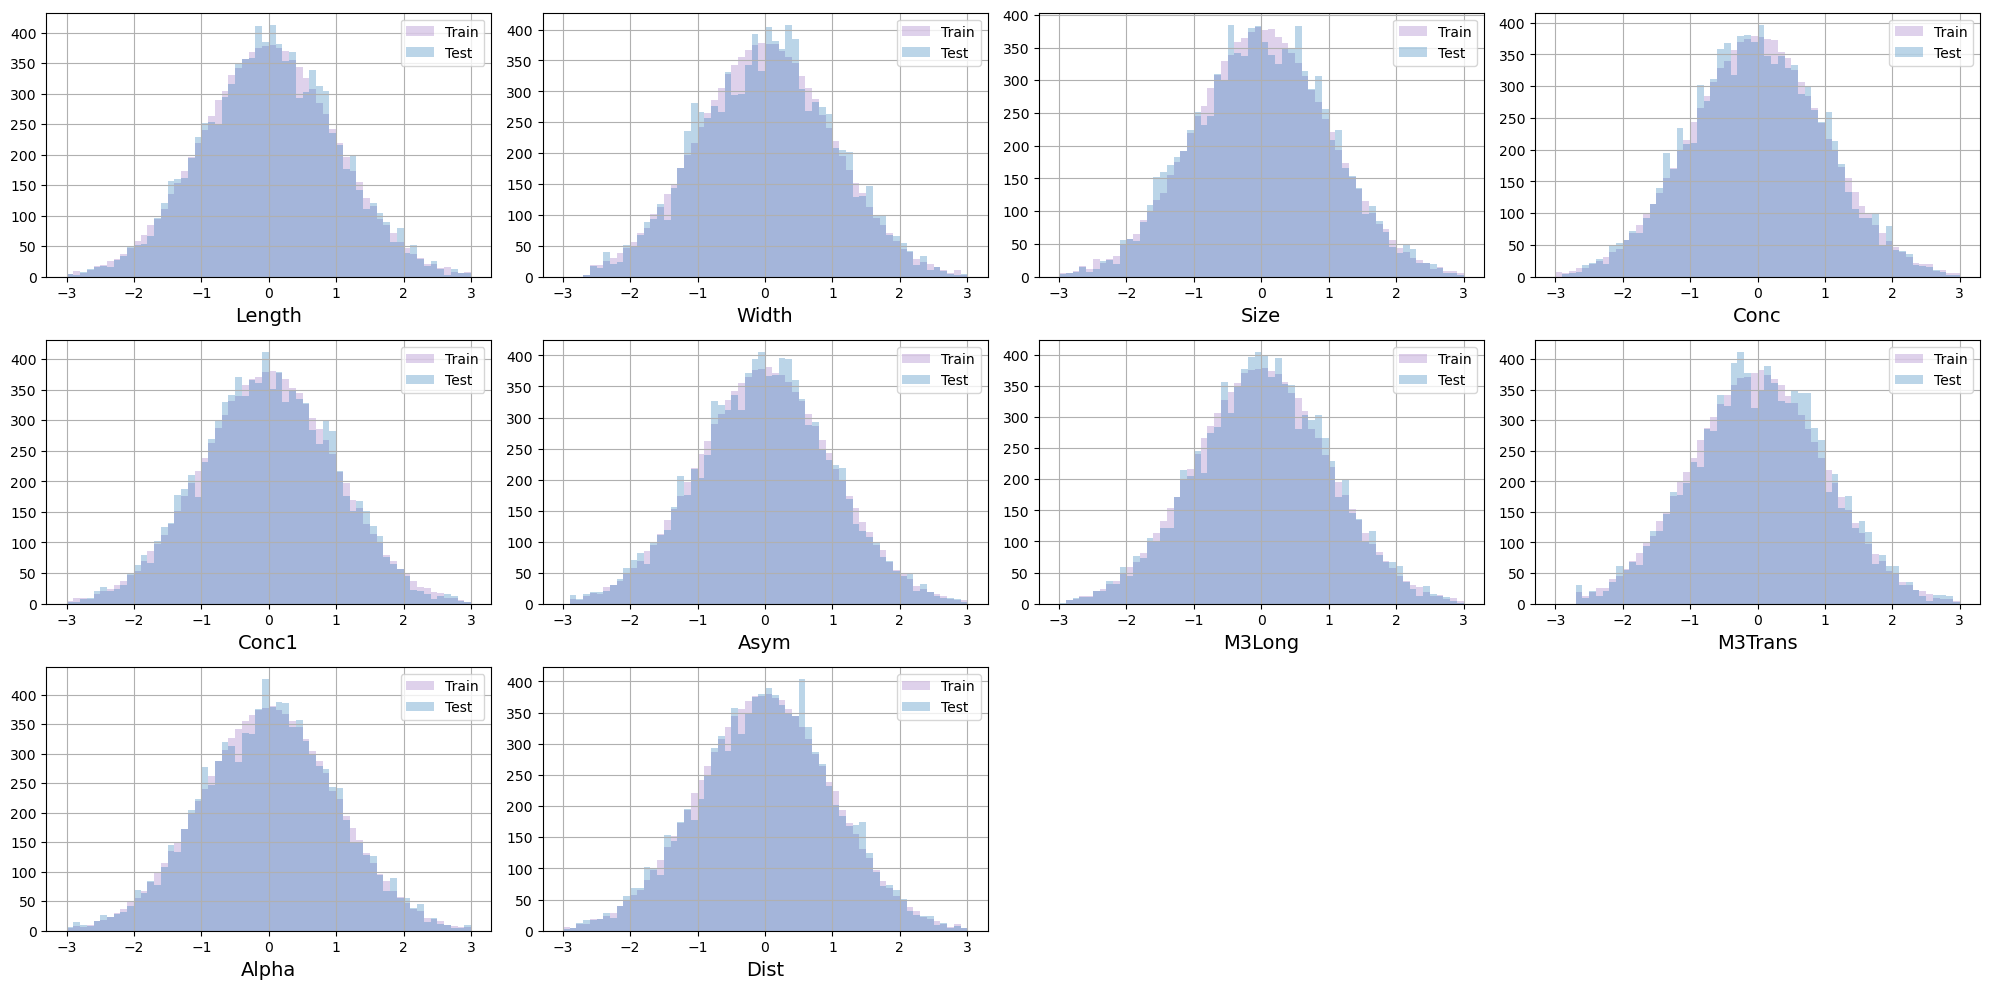

In [ ]:
plot_hists(X_train, X_test, names, label1="Train", label2="Test")

## Model 1: Conditional Wasserstein GAN

The first approach is a conditional Wasserstein GAN (WGAN). The class label is concatenated with the model inputs so that generation can be controlled by particle type: **0** for hadrons and **1** for photons.

<center><img src="img/cgan.png" width="800"></center>

The generator $\hat{x}=G(z,y)$ maps a latent noise vector $z$ and class condition $y$ to a synthetic event vector $\hat{x}$.

The discriminator $D(x,y)$ receives an event vector and its class condition and returns a scalar score. The conditional adversarial objective is expressed as:

$$L(G,D)=-\frac{1}{n}\sum_{x_i\in X, y_i\in y}D(x_i,y_i)-\frac{1}{n}\sum_{z_i\in Z, y_i\in y}D(G(z_i,y_i),y_i) \to \max_G\min_D$$

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, TensorDataset

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [ ]:
DEVICE

device(type='cuda')

### Generator architecture

The generator uses two fully connected hidden layers with 100 units each. Batch normalization and ReLU activations support stable optimization, while the final linear layer produces the ten event features.

In [ ]:
class Generator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super(Generator, self).__init__()

        # Model implementation
        self.final = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, n_outputs)
        )
        # End implementation

    def forward(self, z, y):
        zy = torch.cat((z, y), dim=1)
        return self.final(zy)

### Conditional sample generation

The helper below draws a latent vector for every requested class label, runs the generator in inference mode, and returns the generated event matrix as a NumPy array.

In [ ]:
def generate(generator, y, latent_dim):
    # Model implementation
    fixed_z = torch.normal(0, 1, (len(y), latent_dim)).to(DEVICE)
    y = torch.tensor(y, dtype=torch.float).to(DEVICE)
    X_fake = generator(fixed_z, y).cpu().detach().numpy()
    # End implementation
    return X_fake  # numpy

### Discriminator architecture

The discriminator concatenates the event vector with its class label and processes the result through two 100-unit fully connected layers. A sigmoid output is retained in this implementation to map the final score into the interval $[0,1]$.

For a canonical Wasserstein critic, the output would normally remain linear rather than represent a probability. The current implementation is preserved here as part of the original experiment.

In [ ]:
# A sigmoid maps the discriminator output to a probability-like score for this implementation.
# Note: a canonical Wasserstein critic would typically use an unrestricted linear output.

In [ ]:
class Discriminator(nn.Module):
    def __init__(self, n_inputs):
        super(Discriminator, self).__init__()

        # Model implementation
        self.final = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.ReLU(),
            nn.Linear(100, 1),
            nn.Sigmoid()
        )
        # End implementation

    def forward(self, x, y):
        xy = torch.cat((x, y), dim=1)
        return self.final(xy)

### Independent realism check

To measure how easily synthetic observations can be separated from real ones, the evaluation helper constructs a balanced real-versus-generated dataset, creates a stratified 75/25 split, and trains logistic-regression and gradient-boosting classifiers.

An accuracy close to **0.5** is desirable on a balanced test set: it indicates that the evaluator performs near random chance and cannot reliably distinguish generated events from real observations.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier as GBC
from sklearn.metrics import accuracy_score
def other_agent_score(X_real, y_real, X_fake, y_fake):
    # Model implementation
    fake = torch.tensor([0]).repeat(y_fake.shape[0], 1)
    real = torch.tensor([1]).repeat(y_real.shape[0], 1)
    Xy1 = torch.cat((X_real, y_real), dim= 1)
    Xy2 = torch.cat((X_fake, y_fake), dim= 1)
    Xy = torch.cat((Xy1, Xy2),dim=0).cpu().detach().numpy()
    y = torch.cat((fake, real),dim=0).cpu().detach().numpy()

    X_train,X_test, y_train, y_test = train_test_split(Xy,y, test_size=0.25, stratify=y)
    clf = GBC(n_estimators=100, learning_rate=1.0,
    max_depth=1, random_state=0).fit(X_train, y_train)
    lin = LogisticRegression(random_state=0).fit(X_train, y_train)
    lin_reg_score = accuracy_score(y_test, lin.predict(X_test))
    boosting_score = accuracy_score(y_test, clf.predict(X_test))
    # End implementation
    print('Linear regression score: ' + str(lin_reg_score))
    print('Boosting score: ' + str(boosting_score))

In [ ]:
# On a balanced real-versus-generated dataset, accuracy near 0.5 is the ideal result:
# it means the independent evaluator cannot distinguish synthetic observations from real ones.

### WGAN training pipeline

The training class coordinates generator and discriminator updates. The discriminator is updated `n_critic` times per generator update, and its parameters are clipped to $[-0.01, 0.01]$ to enforce the constraint used by the original WGAN formulation.

In [ ]:
class Fitter(object):
    def __init__(
        self,
        generator,
        discriminator,
        batch_size = 32,
        n_epochs = 10,
        latent_dim = 1,
        lr = 0.0001,
        n_critic=5,
    ):

        self.generator = generator
        self.discriminator = discriminator
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic

        self.opt_gen = torch.optim.RMSprop(self.generator.parameters(), lr=self.lr)
        self.opt_disc = torch.optim.RMSprop(self.discriminator.parameters(), lr=self.lr)

        self.generator.to(DEVICE)
        self.discriminator.to(DEVICE)

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.generator.train(True)
        self.discriminator.train(True)

        self.loss_history = []
        self.gen_loss_trace = []
        self.discr_loss_trace = []
        # Fit GAN
        for epoch in range(self.n_epochs):
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):
                # Model implementation
                # Select real observations
                num_objects = real_batch.shape[0]
                real_batch = real_batch.to(DEVICE)
                cond_batch = cond_batch.to(DEVICE)
                # Generate synthetic observations

                z = torch.normal(0, 1, (num_objects, self.latent_dim)).to(DEVICE)
                fake_batch = self.generator(z, cond_batch)




                if i % self.n_critic == 0:
                # Update the generator
                    self.opt_gen.zero_grad()
                    gen_loss = - torch.mean(self.discriminator(fake_batch, cond_batch))
                    gen_loss.backward()
                    self.opt_gen.step()
                    self.gen_loss_trace.append((i, gen_loss.item()))
                else:
                # Update the discriminator
                    self.opt_disc.zero_grad()
                    discr_loss = - torch.mean(self.discriminator(real_batch, cond_batch)) + torch.mean(self.discriminator(fake_batch, cond_batch))
                    discr_loss.backward()
                    self.opt_disc.step()
                    for p in self.discriminator.parameters():
                        p.data.clamp_(-0.01, 0.01)
                    self.discr_loss_trace.append((i, discr_loss.item()))

                # End implementation

            # caiculate and store loss after an epoch
            Z_noise = torch.normal(0, 1, (len(X_real), self.latent_dim)).to(DEVICE)
            X_fake = self.generator(Z_noise, y_cond)
            loss_epoch =  torch.mean(self.discriminator(X_real, y_cond)) - torch.mean(
                self.discriminator(X_fake, y_cond)
            )
            self.loss_history.append(loss_epoch.detach().cpu())

            # Evaluate 1,000 real training observations against 1,000 generated observations
            # with the independent real-versus-generated classifiers.

            # Model implementation
            indices = torch.randint(1, len(X_real), (1000,))
            X_train = X_real[indices]
            X_gen = X_fake[indices]
            other_agent_score(X_train, y_cond[indices], X_gen, y_cond[indices])
            # End implementation

        # Turn off training
        self.generator.train(False)
        self.discriminator.train(False)

### Training the conditional WGAN

In [ ]:
%%time
latent_dim = 10
generator = Generator(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])
discriminator = Discriminator(n_inputs=X_train.shape[1] + y.shape[1])

fitter = Fitter(
    generator,
    discriminator,
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5,
)
fitter.fit(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Linear regression score: 0.758
Boosting score: 0.94


/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Linear regression score: 0.642
Boosting score: 0.902


/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Linear regression score: 0.57
Boosting score: 0.556


/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Linear regression score: 0.574
Boosting score: 0.548
Linear regression score: 0.582
Boosting score: 0.56
CPU times: user 1min 29s, sys: 8.73 s, total: 1min 37s
Wall time: 1min 25s


/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: MatplotlibDeprecationWarning: The 'b' parameter of grid() has been renamed 'visible' since Matplotlib 3.5; support for the old name will be dropped two minor releases later.
  if __name__ == "__main__":


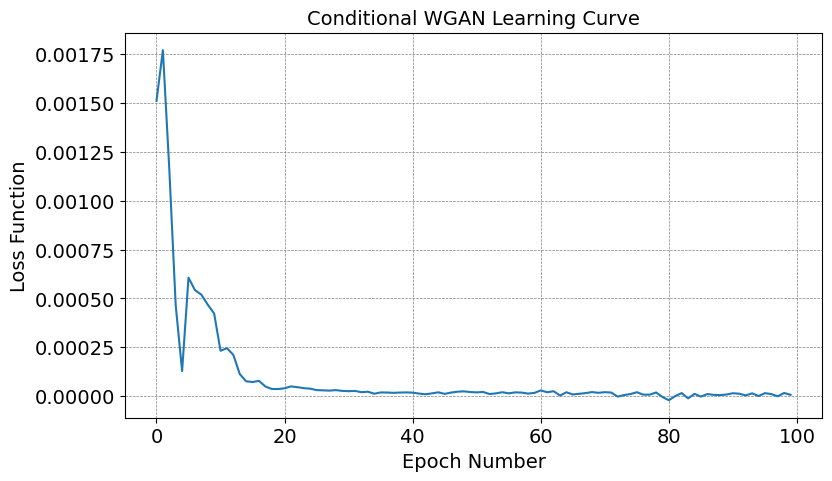

In [ ]:
# WGAN learning curve
plt.figure(figsize=(9, 5))
plt.plot(fitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional WGAN Learning Curve", size=14)
plt.grid(b=1, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

### Generating WGAN samples

Synthetic train and test matrices are generated with the corresponding class labels. Before comparison, both real and generated samples are returned to their original feature scales using the fitted quantile transformer's inverse transformation.

In [ ]:
# Model implementation
X_train = qt.inverse_transform(X_train)
X_test = qt.inverse_transform(X_test)
# End implementation

In [ ]:
X_fake_train = generate(fitter.generator, y_train, latent_dim)
X_fake_train = qt.inverse_transform(X_fake_train)

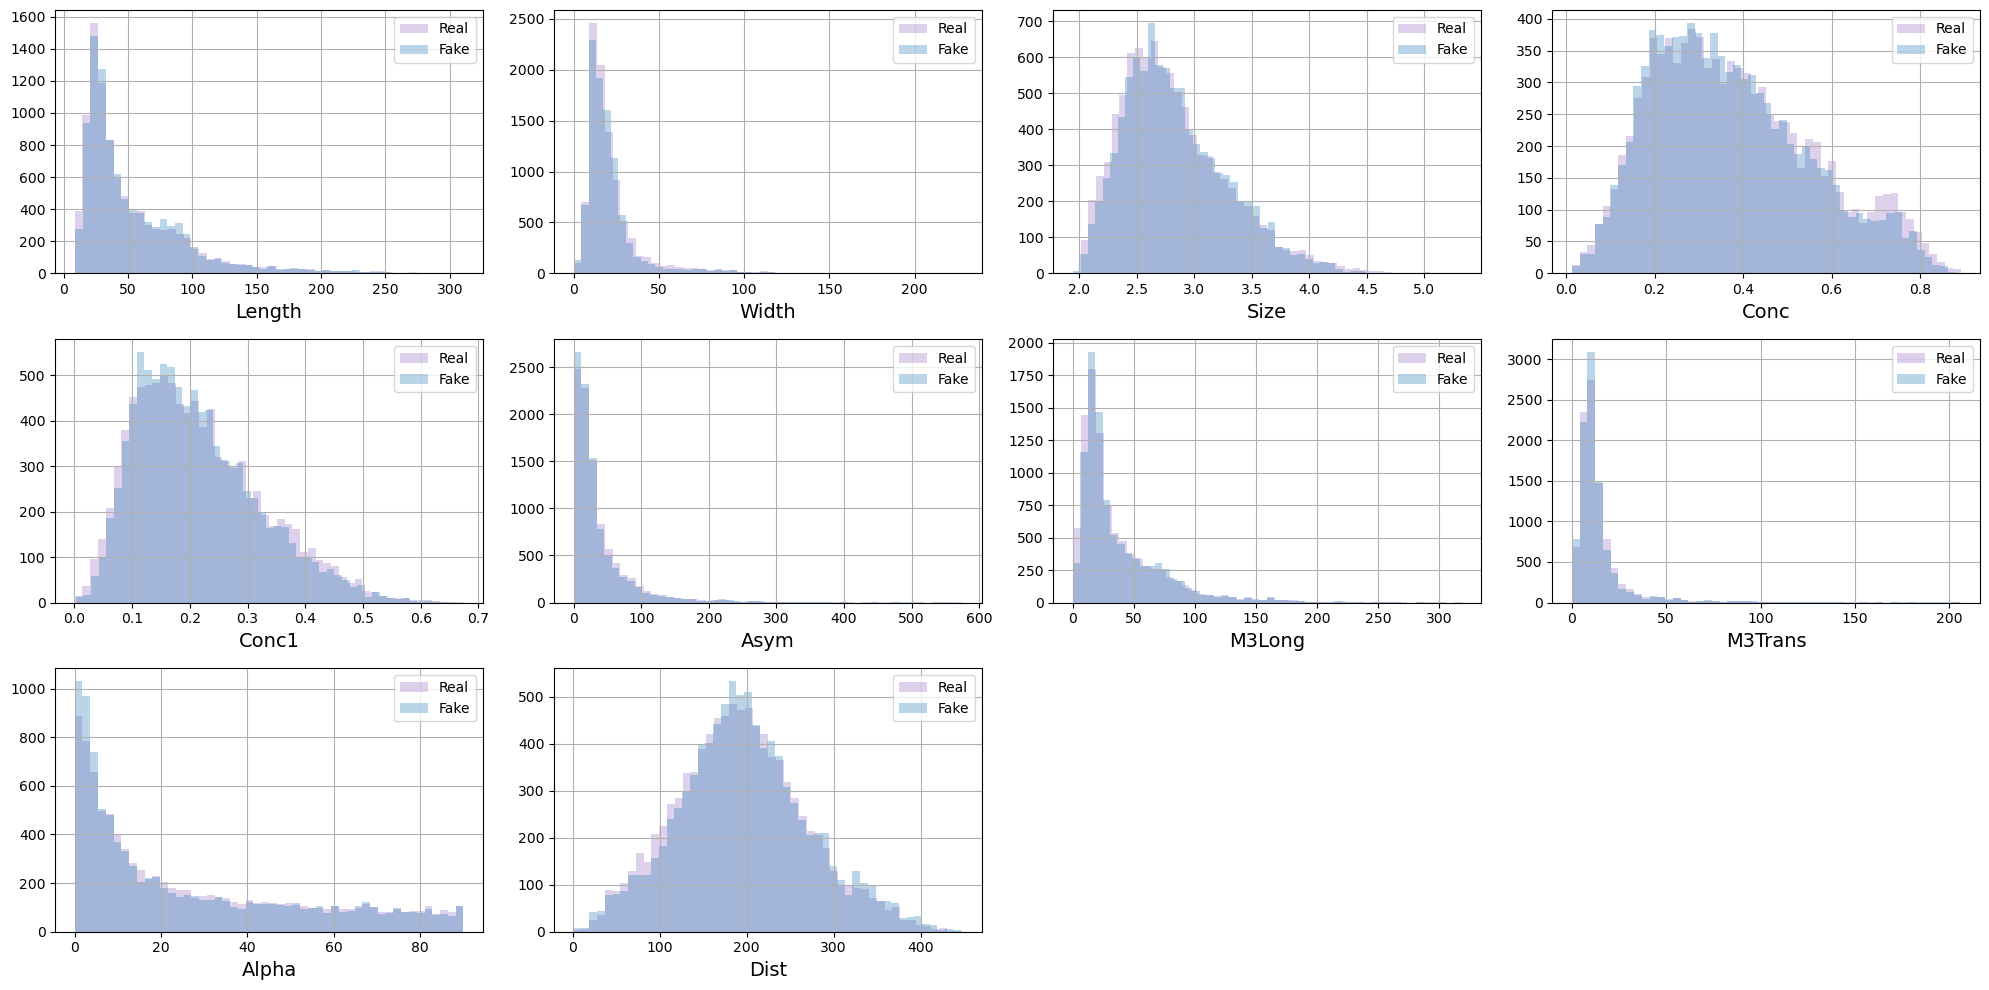

In [ ]:
plot_hists(X_train, X_fake_train, names, label1="Real", label2="Fake", bins=50)

In [ ]:
X_fake_test = generate(fitter.generator, y_test, latent_dim)
X_fake_test = qt.inverse_transform(X_fake_test)

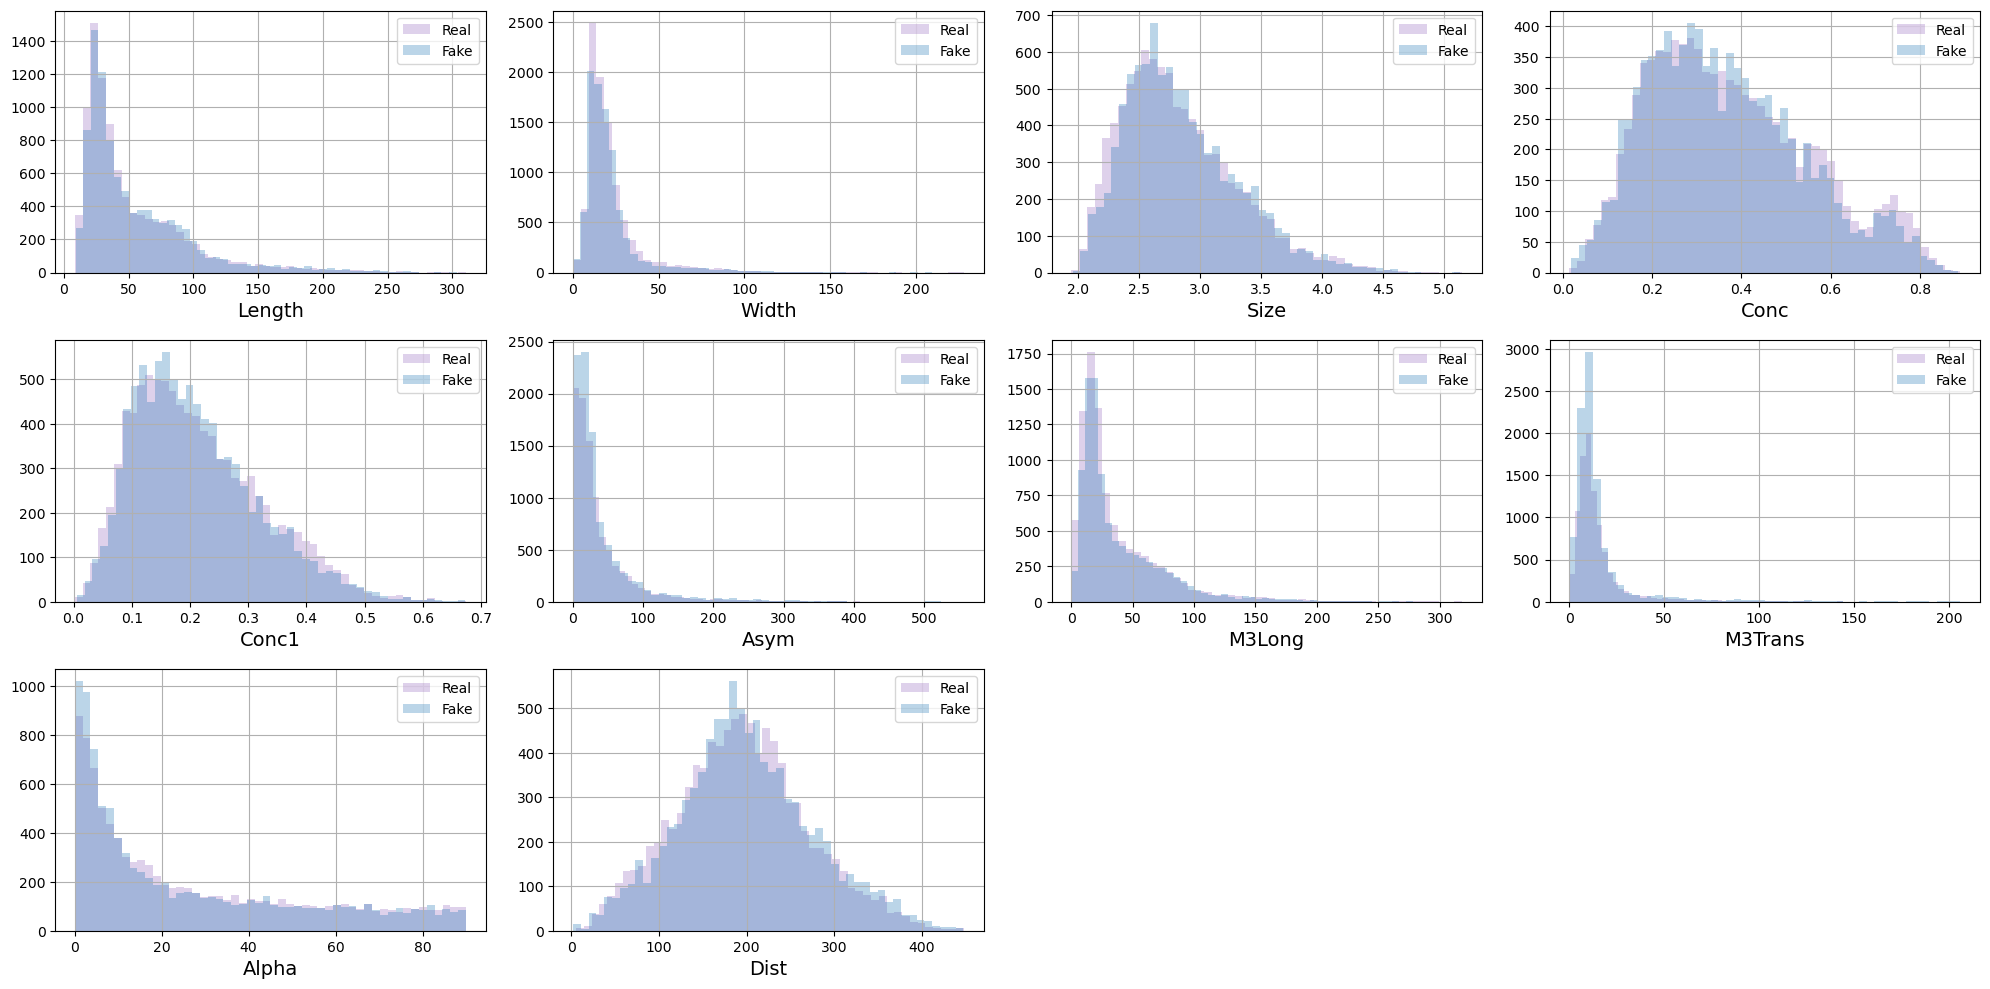

In [ ]:
plot_hists(X_test, X_fake_test, names, label1="Real", label2="Fake", bins=50)

### Initial visual assessment

The univariate histograms show overlap between real and generated feature distributions. This is an encouraging first check, but it does not capture dependencies across the full ten-dimensional feature space. A classifier-based two-sample test provides a stronger evaluation.

## Classifier-based evaluation

<center><img src="img/clf.png" width="600"></center>

A gradient-boosting classifier is trained to distinguish real event vectors from generated ones. ROC AUC summarizes its discrimination ability: values near **0.5** indicate distributions that are difficult to separate, while values approaching **1.0** reveal systematic differences.

In [ ]:
# Combine real and generated samples into one evaluation dataset
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [ ]:
from sklearn.ensemble import GradientBoostingClassifier

# Train the real-versus-generated classifier
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

# Predict real-sample probabilities
yy_test_proba = clf.predict_proba(XX_test)[:, 1]


In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.7176655266856184


### Interpreting WGAN quality

The evaluator's ROC AUC is compared with the ideal chance-level value of 0.5. A score substantially above 0.5 indicates that the generated data capture some—but not all—of the real multivariate structure.

In [ ]:
# The target ROC AUC is close to 0.5, where the evaluator performs at chance level.
# A value closer to 1.0 would show that real and generated events remain readily separable.
# The observed score lies between these extremes: the generator captures meaningful structure,
# although the independent classifier still detects differences in the joint distribution.

## Model 2: Diffusion-based generator

The second experiment applies a compact diffusion-inspired approach to the same normalized, class-conditional event representation. This provides a direct comparison with adversarial generation under a shared preprocessing and evaluation setup.

### Forward corruption process

The corruption function progressively mixes each observation with random noise according to a per-sample noise amount. This creates noisy training inputs from which the model learns to recover structured event vectors.

In [ ]:
X_train = qt.fit_transform(X_train)
X_test = qt.transform(X_test)

In [ ]:
def corrupt(x, amount):
    # Model implementation
    noise = torch.rand_like(x)
    amount = amount.view(-1, 1)
    x = x*(1-amount) + noise * amount
    # End implementation
    return x

### Noise schedule

In [ ]:
#pip install diffusers

In [ ]:
from diffusers import DDPMScheduler

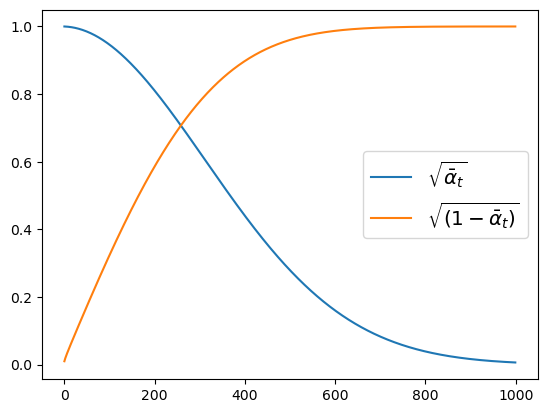

In [ ]:
noise_scheduler = DDPMScheduler(num_train_timesteps=1000, clip_sample_range=3)
plt.plot(noise_scheduler.alphas_cumprod.cpu() ** 0.5, label=r"${\sqrt{\bar{\alpha}_t}}$")
plt.plot((1 - noise_scheduler.alphas_cumprod.cpu()) ** 0.5, label=r"$\sqrt{(1 - \bar{\alpha}_t)}$")
plt.legend(fontsize="x-large")

### Diffusion network architecture

The denoising network follows the generator's compact multilayer-perceptron design: two 100-unit fully connected layers, batch normalization, ReLU activations, and a linear output layer. The particle label is concatenated with the noisy input to preserve class conditioning.

In [ ]:
class DiffusionGenerator(nn.Module):
    def __init__(self, n_inputs, n_outputs):
        super(DiffusionGenerator, self).__init__()

        # Model implementation
        self.final = nn.Sequential(
            nn.Linear(n_inputs, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, 100),
            nn.BatchNorm1d(100),
            nn.ReLU(),
            nn.Linear(100, n_outputs)
        )
        # End implementation
    def forward(self, z, y):
        zy = torch.cat((z, y), dim=1)
        return self.final(zy)

### Diffusion sample generation

The generation helper samples a latent vector and timestep, adds scheduler-controlled noise, and passes the resulting vector and class condition through the trained network.

In [ ]:
def generate_with_diffusion(model, y, latent_dim, scheduler):
    # Model implementation
    #x = torch.randn(len(y), 10).to(DEVICE)
    x = torch.normal(0, 1, (len(y), latent_dim)).to(DEVICE)
    y = torch.tensor(y, dtype=torch.float).to(DEVICE)
    noise = torch.randn(len(y), latent_dim).to(DEVICE)
    timesteps = torch.randint(0, 999, (len(y),)).to(DEVICE)
    noisy_x = scheduler.add_noise(x, noise, timesteps).to(DEVICE)
    X_fake = model(noisy_x, y).cpu().detach().numpy()
    # End implementation
    return X_fake  # numpy

### Diffusion training pipeline

The training loop builds noisy inputs with the DDPM scheduler and optimizes the network using mean squared error. Training loss is retained for convergence analysis.

In [ ]:
class DiffusionFitter(object):
    def __init__(
        self,
        model,
        loss,
        batch_size = 32,
        n_epochs = 10,
        latent_dim = 1,
        lr = 0.0001,
        n_critic=5

    ):

        self.model = model
        self.batch_size = batch_size
        self.n_epochs = n_epochs
        self.latent_dim = latent_dim
        self.lr = lr
        self.n_critic = n_critic
        self.loss = loss

        self.opt_gen = torch.optim.RMSprop(self.model.parameters(), lr=self.lr)

        self.model.to(DEVICE)

    def fit(self, X, y):

        # numpy to tensor
        X_real = torch.tensor(X, dtype=torch.float, device=DEVICE)
        y_cond = torch.tensor(y, dtype=torch.float, device=DEVICE)

        # tensor to dataset
        dataset_real = TensorDataset(X_real, y_cond)

        # Turn on training
        self.model.train(True)

        self.loss_history = []

        # Fit GAN
        for epoch in range(self.n_epochs):
            loss_epoch = 0
            for i, (real_batch, cond_batch) in enumerate(
                DataLoader(dataset_real, batch_size=self.batch_size, shuffle=True)
            ):

                # Model implementation
                real_batch = (real_batch * 2 - 1).to(DEVICE)

                cond_batch = cond_batch.to(DEVICE)
                noise = torch.randn_like(real_batch)
                #noise_amount = torch.rand(real_batch.shape[0]).to(DEVICE) # Pick random noise amounts
                #noisy_x = corrupt(real_batch, noise_amount) # Create our noisy x
                timesteps = torch.randint(0, 999, (real_batch.shape[0],)).long().to(DEVICE)
                noisy_x = noise_scheduler.add_noise(real_batch, noise, timesteps)
                pred = self.model(noisy_x, cond_batch)

                # Calculate the loss
                loss1 = self.loss(pred, noise) # How close is the output to the noise
                # Backprop and update the params:
                self.opt_gen.zero_grad()
                loss1.backward()
                self.opt_gen.step()
                loss_epoch += loss1.item()

                # End implementation

            # caiculate and store loss after an epoch

            self.loss_history.append(loss_epoch/self.batch_size)

            # Evaluate 1,000 real training observations against 1,000 generated observations
            # with the independent real-versus-generated classifiers.

            # Model implementation
            noise = torch.randn_like(X_real)
            timesteps = torch.randint(0, 999, (X_real.shape[0],)).long().to(DEVICE)
            noisy_x = noise_scheduler.add_noise(X_real, noise, timesteps)
            #noise_amount = torch.rand(X_real.shape[0]).to(DEVICE)
            #noisy_x = corrupt(X_real, noise_amount)
            X_fake = self.model(noisy_x, y_cond)
            indices = torch.randint(1, len(X_real), (1000,))
            X_train = X_real[indices]
            X_gen = X_fake[indices]
            other_agent_score(X_train, y_cond[indices], X_gen, y_cond[indices])
            # End implementation

        # Turn off training
        self.model.train(False)

In [ ]:
%%time
latent_dim = 10
model = DiffusionGenerator(n_inputs=latent_dim + y.shape[1], n_outputs=X_train.shape[1])

diffusionFitter = DiffusionFitter(
    model,
    loss = nn.MSELoss(),
    batch_size=50,
    n_epochs=100,
    latent_dim=latent_dim,
    lr=0.0001,
    n_critic=5

)
diffusionFitter.fit(X_train, y_train)

/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Linear regression score: 0.53
Boosting score: 0.79


/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Linear regression score: 0.494
Boosting score: 0.672


/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


...

/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Linear regression score: 0.524
Boosting score: 0.6


/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


Linear regression score: 0.52
Boosting score: 0.58
Linear regression score: 0.456
Boosting score: 0.582
CPU times: user 1min 15s, sys: 7.94 s, total: 1min 23s
Wall time: 1min 11s


/opt/conda/lib/python3.7/site-packages/sklearn/ensemble/_gb.py:494: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
/opt/conda/lib/python3.7/site-packages/sklearn/utils/validation.py:993: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:9: MatplotlibDeprecationWarning: The 'b' parameter of grid() has been renamed 'visible' since Matplotlib 3.5; support for the old name will be dropped two minor releases later.
  if __name__ == "__main__":


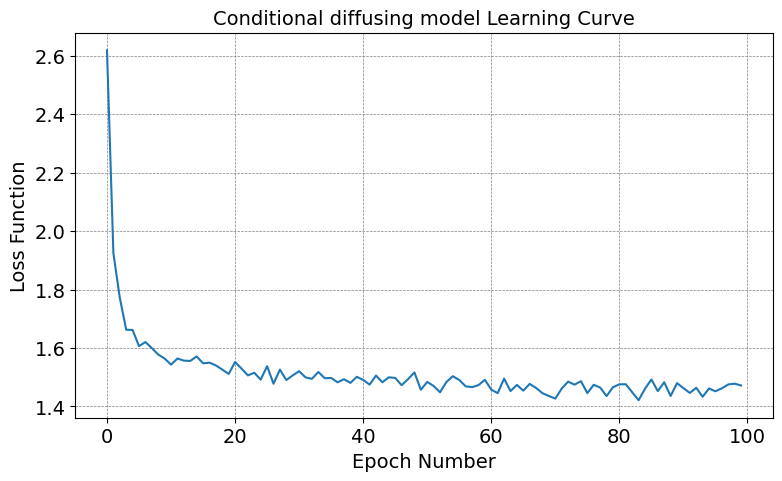

In [ ]:
# diffusion learning curve
plt.figure(figsize=(9, 5))
plt.plot(diffusionFitter.loss_history)
plt.xlabel("Epoch Number", size=14)
plt.ylabel("Loss Function", size=14)
plt.xticks(size=14)
plt.yticks(size=14)
plt.title("Conditional diffusing model Learning Curve", size=14)
plt.grid(b=1, linestyle="--", linewidth=0.5, color="0.5")
plt.show()

### Evaluating diffusion-generated events

The diffusion model is evaluated with the same protocol used for the WGAN: generate a test-sized synthetic sample, invert the quantile transformation, inspect feature distributions, and train a gradient-boosting classifier to separate real from generated events. ROC AUC and accuracy provide comparable measures of realism.

In [ ]:
X_train = qt.inverse_transform(X_train)
X_test = qt.inverse_transform(X_test)

In [ ]:
X_fake_train = generate_with_diffusion(fitter.generator, y_train, latent_dim, noise_scheduler)
X_fake_train = qt.inverse_transform(X_fake_train)

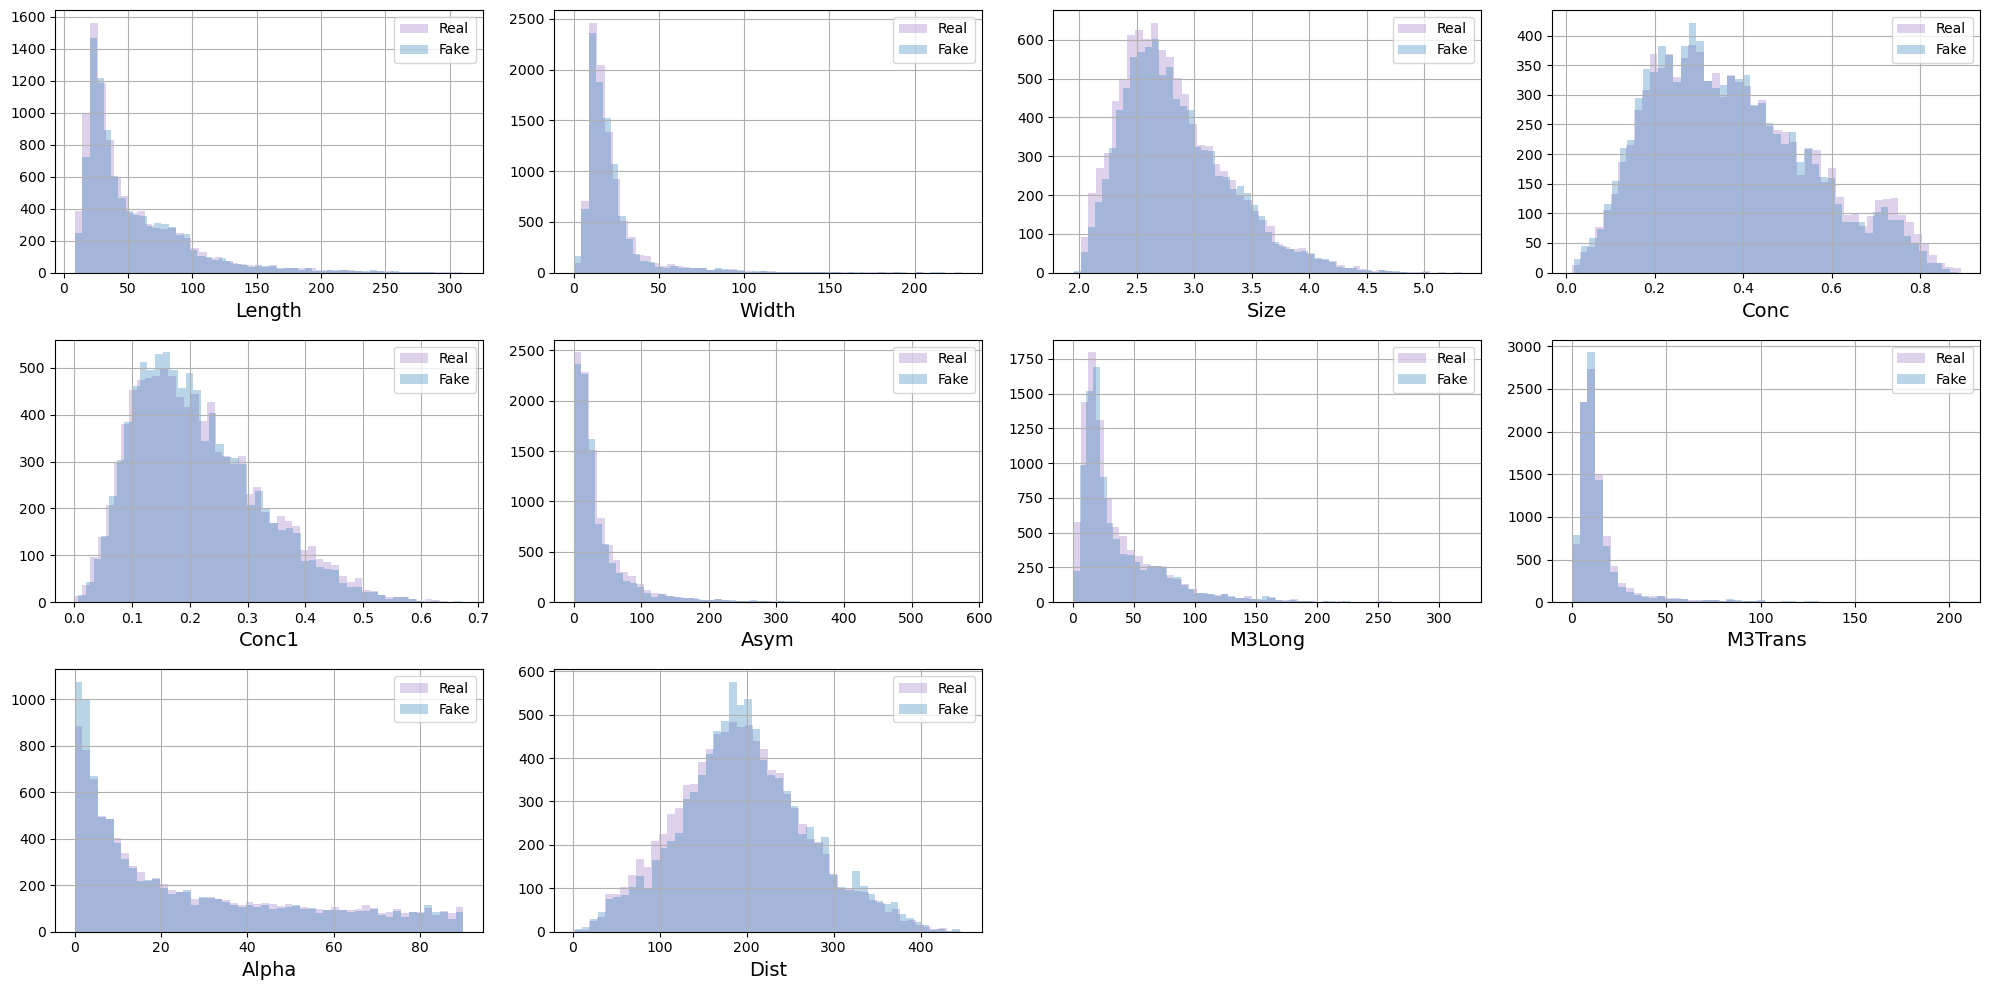

In [ ]:
plot_hists(X_train, X_fake_train, names, label1="Real", label2="Fake", bins=50)

In [ ]:
X_fake_test = generate_with_diffusion(fitter.generator, y_test, latent_dim, noise_scheduler)
X_fake_test = qt.inverse_transform(X_fake_test)

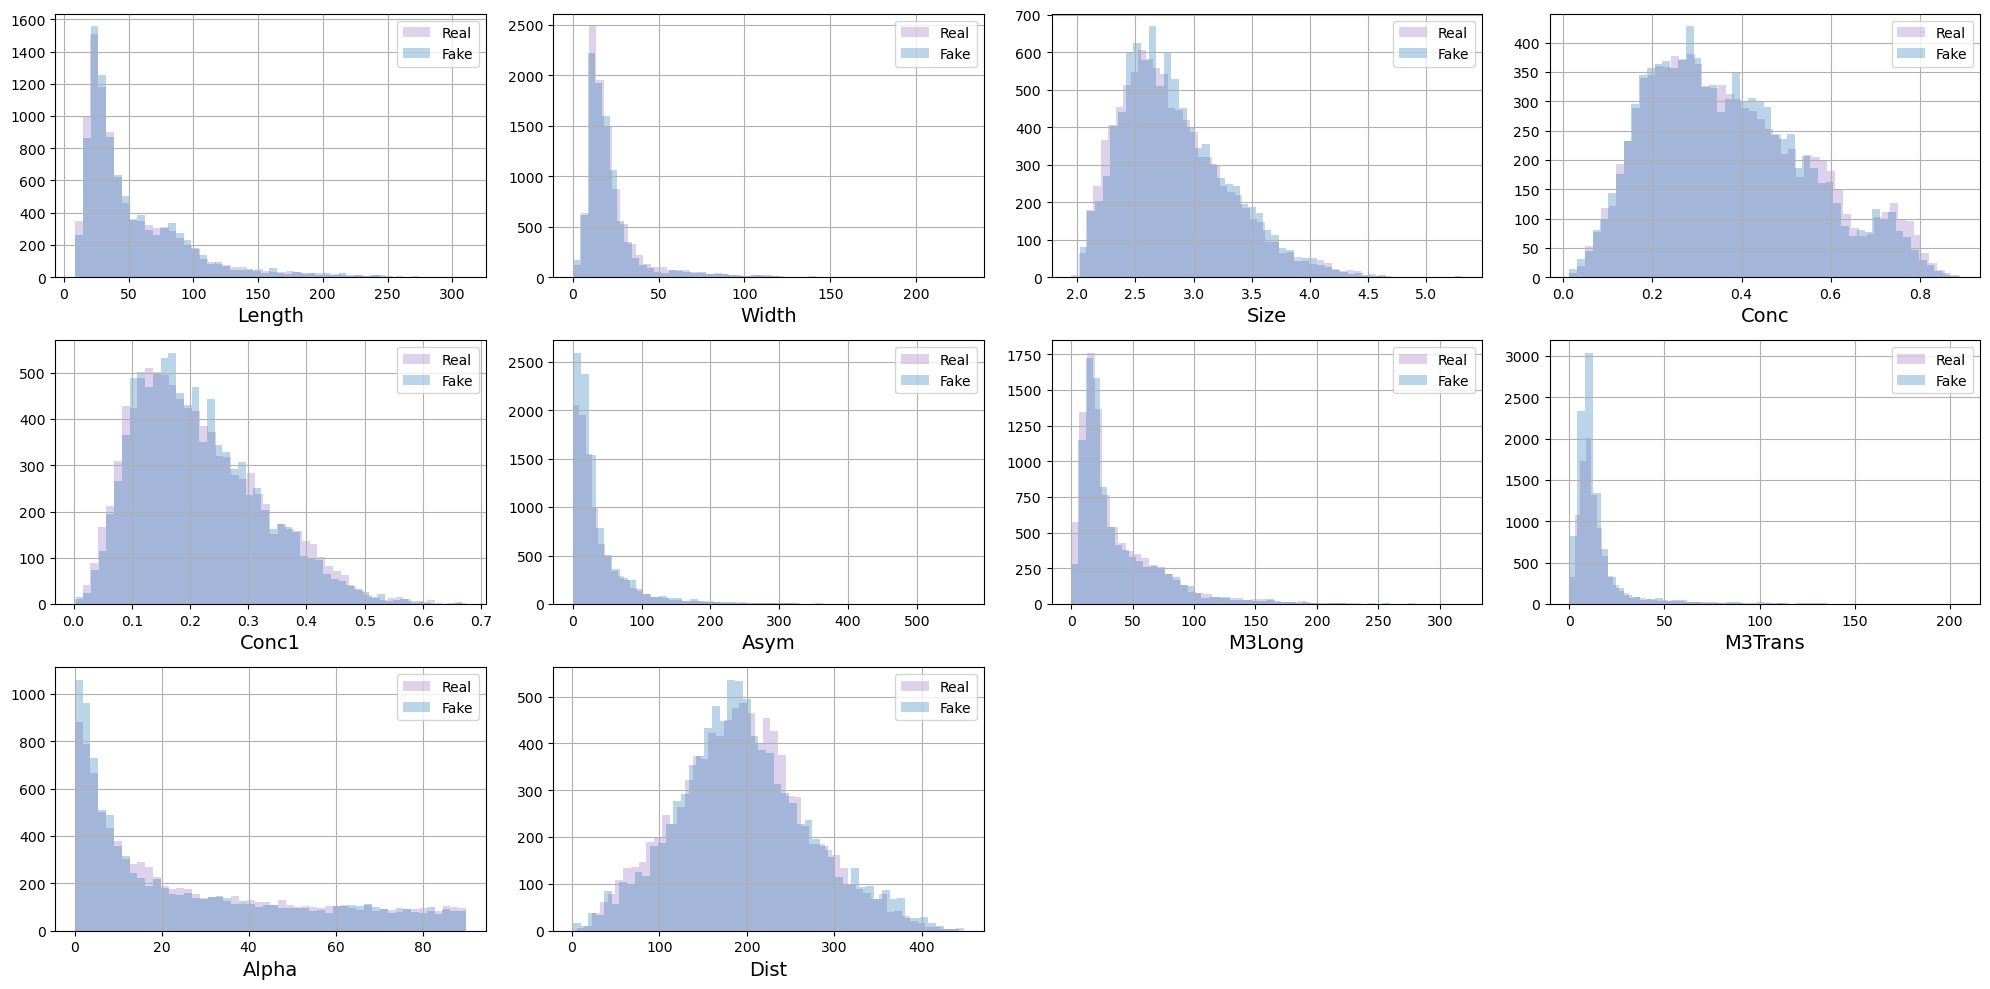

In [ ]:
plot_hists(X_test, X_fake_test, names, label1="Real", label2="Fake", bins=50)

In [ ]:
# Combine real and generated samples into one evaluation dataset
XX_train = np.concatenate((X_fake_train, X_train), axis=0)
XX_test = np.concatenate((X_fake_test, X_test), axis=0)

yy_train = np.array([0] * len(X_fake_train) + [1] * len(X_train))
yy_test = np.array([0] * len(X_fake_test) + [1] * len(X_test))

In [ ]:
clf = GradientBoostingClassifier()
clf.fit(XX_train, yy_train)

# Predict real-sample probabilities
yy_test_proba = clf.predict_proba(XX_test)[:, 1]
auc = roc_auc_score(yy_test, yy_test_proba)
print("ROC AUC = ", auc)

ROC AUC =  0.71338730828471


In [ ]:
# The two approaches produce broadly similar ROC AUC values in this experiment.
# Because the score is below 1.0, generated and real observations are not perfectly separable;
# however, the distance from 0.5 shows that both generators leave detectable artifacts.

## Conclusions

This project established an end-to-end workflow for conditional generation of MAGIC telescope event parameters:

1. Explore and normalize ten-dimensional Hillas features.
2. Train a conditional WGAN and a diffusion-based generator.
3. Restore generated samples to their original feature space.
4. Evaluate realism through distribution plots and classifier-based two-sample tests.

The experiments show that both model families can reproduce part of the observed feature structure, while the evaluator scores indicate that measurable differences remain. Potential extensions include a linear WGAN critic, gradient-penalty regularization, a more complete reverse-diffusion sampling procedure, hyperparameter tuning, and multivariate diagnostics beyond marginal histograms.

In [ ]:
# End of the reproducible experiment.